# How to transform data into factors

Based on a conceptual understanding of key factor categories, their rationale and popular metrics, a key task is to identify new factors that may better capture the risks embodied by the return drivers laid out previously, or to find new ones. 

In either case, it will be important to compare the performance of innovative factors to that of known factors to identify incremental signal gains.

We create the dataset here and store it in our [data](../../data) folder to facilitate reuse in later chapters.

## Imports & Settings

In [57]:
import warnings
warnings.filterwarnings('ignore')

In [58]:
%matplotlib inline

from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pandas_datareader.data as web
#from pyfinance.ols import PandasRollingOLS

In [59]:
sns.set_style('whitegrid')
idx = pd.IndexSlice

## Get Data

The `assets.h5` store can be generated using the the notebook [create_datasets](../../data/create_datasets.ipynb) in the [data](../../data) directory in the root directory of this repo for instruction to download the following dataset.

We load the Quandl stock price datasets covering the US equity markets 2000-18 using `pd.IndexSlice` to perform a slice operation on the `pd.MultiIndex`, select the adjusted close price and unpivot the column to convert the DataFrame to wide format with tickers in the columns and timestamps in the rows:

Set data store location:

In [60]:
tickers = []
with open('SP500-tickers.csv', 'r') as file:
    # Read each line in the file
    for line in file:
        # Process the line (e.g., print it)
        tickers.append(line.strip().replace(".", "-"))

print(tickers)

['MSFT', 'AAPL', 'NVDA', 'AMZN', 'GOOGL', 'META', 'BRK-B', 'AVGO', 'TSLA', 'WMT', 'LLY', 'JPM', 'V', 'MA', 'NFLX', 'XOM', 'COST', 'ORCL', 'JNJ', 'PG', 'HD', 'UNH', 'ABBV', 'KO', 'BAC', 'TMUS', 'PM', 'CRM', 'PLTR', 'WFC', 'CVX', 'CSCO', 'ABT', 'IBM', 'MCD', 'GE', 'LIN', 'T', 'NOW', 'MRK', 'AXP', 'ISRG', 'ACN', 'MS', 'VZ', 'DIS', 'PEP', 'INTU', 'UBER', 'RTX', 'BKNG', 'PGR', 'BX', 'ADBE', 'GS', 'AMD', 'QCOM', 'TMO', 'BSX', 'SPGI', 'SCHW', 'CAT', 'TXN', 'AMGN', 'SYK', 'TJX', 'BLK', 'BA', 'NEE', 'HON', 'DHR', 'C', 'PFE', 'CMCSA', 'DE', 'UNP', 'LOW', 'AMAT', 'PANW', 'ADP', 'GILD', 'ETN', 'CB', 'VRTX', 'MMC', 'COP', 'LMT', 'GEV', 'MDT', 'CRWD', 'ANET', 'AMT', 'FI', 'KKR', 'MO', 'CME', 'SO', 'ICE', 'PLD', 'WELL', 'ADI', 'BMY', 'APH', 'DUK', 'WM', 'ELV', 'LRCX', 'SBUX', 'MCK', 'MU', 'TT', 'KLAC', 'CI', 'SHW', 'INTC', 'MDLZ', 'AJG', 'NKE', 'CTAS', 'CEG', 'EQIX', 'HCA', 'CVS', 'MCO', 'CDNS', 'FTNT', 'PH', 'ORLY', 'UPS', 'TDG', 'RSG', 'DASH', 'AON', 'ABNB', 'MMM', 'APO', 'SNPS', 'CL', 'GD', 'WMB',

In [61]:
import yfinance as yf
import pandas as pd

# # Define tickers and date range
# tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
start_date = '2020-01-01'
end_date = '2023-01-01'

# Download full OHLCV data
data = yf.download(tickers, start=start_date, end=end_date)

# Reshape so that Ticker is part of the index (Date, Ticker)
data = data.stack(level=1).rename_axis(['Date', 'Ticker']).reset_index()
data.set_index(['Date', 'Ticker'], inplace=True)
data.sort_index(inplace=True)

# Fetch metadata
metadata = []
for ticker in tickers:
    info = yf.Ticker(ticker).info
    ipo_ms = info.get('firstTradeDateMilliseconds')
    ipo_year = pd.to_datetime(ipo_ms, unit='ms').year if ipo_ms else None
    metadata.append({
        'ticker': ticker,
        'marketcap': info.get('marketCap'),
        'ipoyear': ipo_year,
        'sector': info.get('sector')
    })

stocks = pd.DataFrame(metadata).set_index('ticker')

# Save to HDF5
with pd.HDFStore('data_store.h5') as store:
    store.put('prices', data)
    store.put('stocks', stocks)

print("Data saved to 'data_store.h5' with MultiIndex (Date, Ticker)")


[*********************100%***********************]  502 of 502 completed

5 Failed downloads:
['GEV', 'KVUE', 'SOLV', 'VLTO', 'SW']: YFPricesMissingError('possibly delisted; no price data found  (1d 2020-01-01 -> 2023-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1577854800, endDate = 1672549200")')


Data saved to 'data_store.h5' with MultiIndex (Date, Ticker)


In [63]:
import pandas as pd

DATA_STORE = 'data_store.h5'

with pd.HDFStore(DATA_STORE) as store:
    # Load prices and stocks
    prices = store['prices']
    stocks = store['stocks'].loc[:, ['marketcap', 'ipoyear', 'sector']]

    # Filter by date range on the first level of the MultiIndex
    prices = prices.loc[
        (prices.index.get_level_values('Date') >= pd.to_datetime(start_date)) &
        (prices.index.get_level_values('Date') <= pd.to_datetime(end_date))
    ]

    # Select only the 'Close' column and ensure it's a flat DataFrame
    prices = prices[['Close']].copy()
    prices.columns.name = None  # Remove column level name if present
    print(prices.head())

#
# DATA_STORE = 'data_store.h5'
#
# with pd.HDFStore(DATA_STORE) as store:
#     print(store.prices)
#
#     # Ensure START and END are strings or datetime objects
#     prices = store['prices']
#     prices = prices.loc[pd.to_datetime(start_date):pd.to_datetime(end_date)]
#
#     stocks = store['stocks'].loc[:, ['marketcap', 'ipoyear', 'sector']]


# with pd.HDFStore(DATA_STORE) as store:
#     prices = (store['quandl/wiki/prices']
#               .loc[idx[str(START):str(END), :], 'adj_close']
#               .unstack('ticker'))
#     stocks = store['us_equities/stocks'].loc[:, ['marketcap', 'ipoyear', 'sector']]

                       Close
Date       Ticker           
2020-01-02 A       82.885246
           AAPL    72.620827
           ABBV    70.934235
           ABT     78.908409
           ACGL    41.268997


In [64]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 373423 entries, (Timestamp('2020-01-02 00:00:00'), 'A') to (Timestamp('2022-12-30 00:00:00'), 'ZTS')
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Close   373423 non-null  float64
dtypes: float64(1)
memory usage: 4.3+ MB


In [65]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 502 entries, MSFT to CZR
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   marketcap  502 non-null    int64  
 1   ipoyear    501 non-null    float64
 2   sector     502 non-null    object 
dtypes: float64(1), int64(1), object(1)
memory usage: 15.7+ KB


### Keep data with stock info

Remove `stocks` duplicates and align index names for later joining.

In [66]:
stocks = stocks[~stocks.index.duplicated()]
stocks.index.name = 'ticker'

Get tickers with both price information and metdata

In [67]:
shared = prices.columns.intersection(stocks.index)

In [68]:
stocks = stocks.loc[shared, :]
stocks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   marketcap  0 non-null      int64  
 1   ipoyear    0 non-null      float64
 2   sector     0 non-null      object 
dtypes: float64(1), int64(1), object(1)
memory usage: 0.0+ bytes


In [69]:
prices = prices.loc[:, shared]
prices.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 373423 entries, (Timestamp('2020-01-02 00:00:00'), 'A') to (Timestamp('2022-12-30 00:00:00'), 'ZTS')
Empty DataFrame


In [70]:
assert prices.shape[1] == stocks.shape[0]

## Create monthly return series

To reduce training time and experiment with strategies for longer time horizons, we convert the business-daily data to month-end frequency using the available adjusted close price:

In [77]:
# Load the HDF5 file
with pd.HDFStore('data_store.h5') as store:
    prices = store['prices']
    stocks = store['stocks']

# Remove column level name if present
prices.columns.name = None

# Access the 'Close' prices
close_prices = prices['Close']

# Ensure 'Date' level is datetime and resample monthly
if isinstance(prices.index, pd.MultiIndex) and 'Date' in prices.index.names:
    prices.index = prices.index.set_levels(
        pd.to_datetime(prices.index.levels[0]), level='Date'
    )
    monthly_prices = close_prices.unstack('Ticker').resample('M').last()
else:
    raise TypeError("Expected a MultiIndex with 'Date' as one of the levels.")


To capture time series dynamics that reflect, for example, momentum patterns, we compute historical returns using the method `.pct_change(n_periods)`, that is, returns over various monthly periods as identified by lags.

We then convert the wide result back to long format with the `.stack()` method, use `.pipe()` to apply the `.clip()` method to the resulting `DataFrame`, and winsorize returns at the [1%, 99%] levels; that is, we cap outliers at these percentiles.

Finally, we normalize returns using the geometric average. After using `.swaplevel()` to change the order of the `MultiIndex` levels, we obtain compounded monthly returns for six periods ranging from 1 to 12 months:

In [78]:
monthly_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 36 entries, 2020-01-31 to 2022-12-31
Freq: ME
Columns: 497 entries, A to ZTS
dtypes: float64(497)
memory usage: 140.1 KB


In [80]:
with pd.HDFStore('data_store.h5') as store:
    prices = store['prices']
    print("Date range in stored prices:")
    print(prices.index.min(), "to", prices.index.max())
    print(prices.head())


# Assuming prices is already loaded and valid

monthly_prices = prices['Close'].unstack('Ticker').resample('M').last()


outlier_cutoff = 0.01
lags = [1, 2, 3, 6, 9, 12]
returns = {}

for lag in lags:
    returns[f'return_{lag}m'] = (
        monthly_prices
        .pct_change(lag)
        .stack()
        .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                               upper=x.quantile(1 - outlier_cutoff)))
        .add(1)
        .pow(1 / lag)
        .sub(1)
    )

# Combine into a single DataFrame with MultiIndex (date, ticker)
data = pd.concat(returns.values(), axis=1, keys=returns.keys())
data = data.dropna()

# Inspect the result
print(data.info())
print(data.head())

# outlier_cutoff = 0.01
# data = pd.DataFrame()
# lags = [1, 2, 3, 6, 9, 12]
# for lag in lags:
#     data[f'return_{lag}m'] = (monthly_prices
#                            .pct_change(lag)
#                            .stack()
#                            .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
#                                                   upper=x.quantile(1-outlier_cutoff)))
#                            .add(1)
#                            .pow(1/lag)
#                            .sub(1)
#                            )
# data = data.swaplevel().dropna()
# data.info()

Date range in stored prices:
(Timestamp('2020-01-02 00:00:00'), 'A') to (Timestamp('2022-12-30 00:00:00'), 'ZTS')
Price              Adj Close      Close       High        Low       Open  \
Date       Ticker                                                          
2020-01-02 A             NaN  82.885246  83.270985  82.161989  82.837034   
           AAPL          NaN  72.620827  72.681274  71.373203  71.627077   
           ABBV          NaN  70.934235  70.950074  70.110430  70.561938   
           ABT           NaN  78.908409  78.917486  77.864773  78.100722   
           ACGL          NaN  41.268997  41.268997  40.774530  40.898144   

Price                   Volume  
Date       Ticker               
2020-01-02 A         1410500.0  
           AAPL    135480400.0  
           ABBV      5639200.0  
           ABT       4969000.0  
           ACGL      1376700.0  
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11833 entries, (Timestamp('2021-01-31 00:00:00'), 'A') to (Timestamp('20

## Drop stocks with less than 10 yrs of returns

In [81]:
min_obs = 1
nobs = data.groupby(level='Ticker').size()
keep = nobs[nobs > min_obs].index

# Sort index before slicing
data = data.sort_index()
data = data.loc[pd.IndexSlice[:, keep], :]
data.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11833 entries, (Timestamp('2021-01-31 00:00:00'), 'A') to (Timestamp('2022-12-31 00:00:00'), 'ZTS')
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   return_1m   11833 non-null  float64
 1   return_2m   11833 non-null  float64
 2   return_3m   11833 non-null  float64
 3   return_6m   11833 non-null  float64
 4   return_9m   11833 non-null  float64
 5   return_12m  11833 non-null  float64
dtypes: float64(6)
memory usage: 610.8+ KB


In [82]:
data.describe()

,return_1m,return_2m,return_3m,return_6m,return_9m,return_12m
count,11833.000000,11833.000000,11833.000000,11833.000000,11833.000000,11833.000000
mean,0.008877,0.008498,0.009487,0.009949,0.011712,0.013489
std,0.091086,0.060291,0.048455,0.037079,0.031345,0.027365
min,-0.252607,-0.191836,-0.126089,-0.086552,-0.071983,-0.057639
25%,-0.051703,-0.029524,-0.021161,-0.013063,-0.007871,-0.004171
50%,0.006763,0.007700,0.008885,0.009906,0.011382,0.013067
75%,0.065349,0.046028,0.040514,0.032205,0.031128,0.030484
max,0.310651,0.199703,0.155547,0.117457,0.097200,0.085155


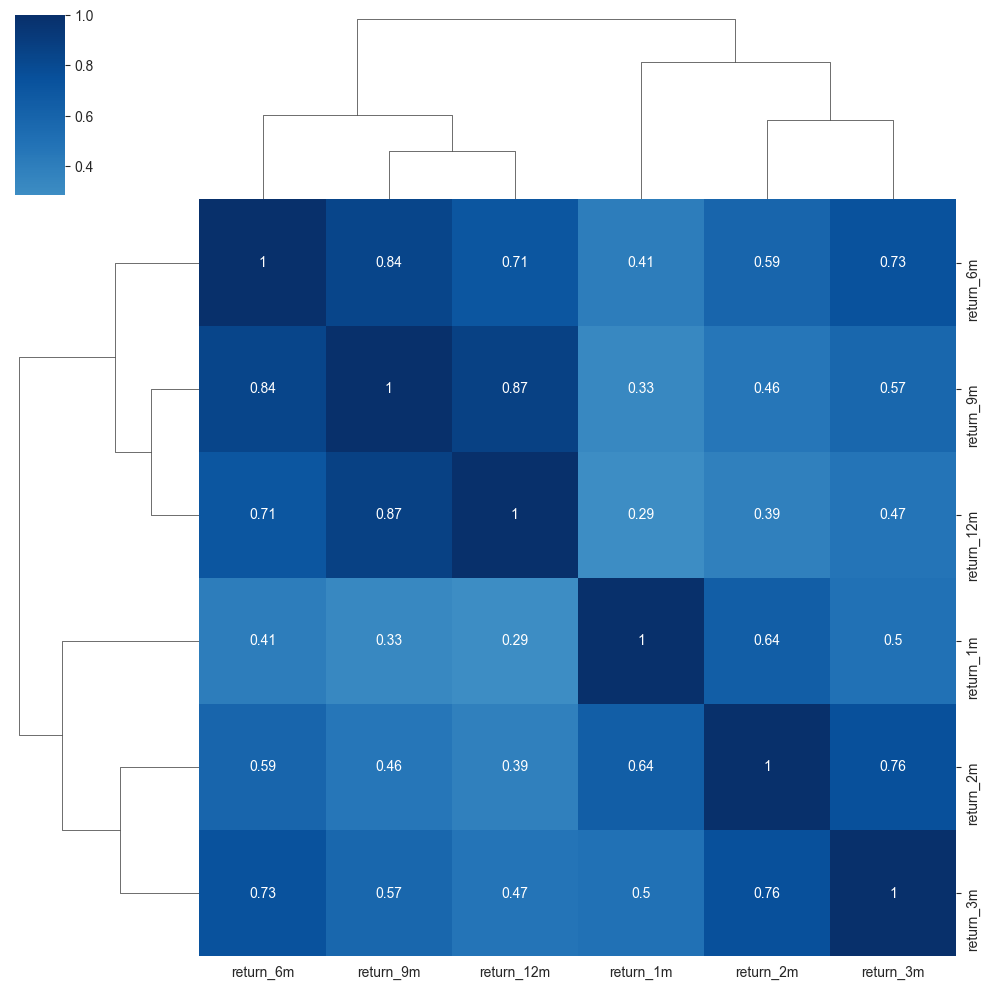

In [83]:
# cmap = sns.diverging_palette(10, 220, as_cmap=True)
sns.clustermap(data.corr('spearman'), annot=True, center=0, cmap='Blues');

We are left with 1,670 tickers.

In [84]:
data.index.get_level_values('Ticker').nunique()

495

## Rolling Factor Betas

We will introduce the Fama—French data to estimate the exposure of assets to common risk factors using linear regression in [Chapter 8, Time Series Models]([](../../08_time_series_models)).

The five Fama—French factors, namely market risk, size, value, operating profitability, and investment have been shown empirically to explain asset returns and are commonly used to assess the risk/return profile of portfolios. Hence, it is natural to include past factor exposures as financial features in models that aim to predict future returns.

We can access the historical factor returns using the `pandas-datareader` and estimate historical exposures using the `PandasRollingOLS` rolling linear regression functionality in the `pyfinance` library as follows:

Use Fama-French research factors to estimate the factor exposures of the stock in the dataset to the 5 factors market risk, size, value, operating profitability and investment.

In [85]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='2000')[0].drop('RF', axis=1)
factor_data.index = factor_data.index.to_timestamp()
factor_data = factor_data.resample('M').last().div(100)
factor_data.index.name = 'Date'
factor_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 304 entries, 2000-01-31 to 2025-04-30
Freq: ME
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Mkt-RF  304 non-null    float64
 1   SMB     304 non-null    float64
 2   HML     304 non-null    float64
 3   RMW     304 non-null    float64
 4   CMA     304 non-null    float64
dtypes: float64(5)
memory usage: 14.2 KB


In [86]:
factor_data = factor_data.join(data['return_1m']).sort_index()
factor_data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11833 entries, (Timestamp('2021-01-31 00:00:00'), 'A') to (Timestamp('2022-12-31 00:00:00'), 'ZTS')
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Mkt-RF     11833 non-null  float64
 1   SMB        11833 non-null  float64
 2   HML        11833 non-null  float64
 3   RMW        11833 non-null  float64
 4   CMA        11833 non-null  float64
 5   return_1m  11833 non-null  float64
dtypes: float64(6)
memory usage: 631.5+ KB


In [87]:
import statsmodels.api as sm
import pandas as pd

def rolling_ols(y, x, window):
    betas = []
    for i in range(window, len(y) + 1):
        y_window = y.iloc[i - window:i]
        x_window = x.iloc[i - window:i]
        x_window = sm.add_constant(x_window)
        model = sm.OLS(y_window, x_window).fit()
        betas.append(model.params)
    return pd.DataFrame(betas, index=y.index[window - 1:])

T = 24

# Run rolling regression grouped by ticker
betas = (
    factor_data
    .groupby(level='Ticker', group_keys=False)
    .apply(lambda x: rolling_ols(x['return_1m'], x.drop(columns='return_1m'), window=min(T, x.shape[0]-1)))
)

print(betas.head())


                      const    Mkt-RF       SMB       HML       RMW       CMA
Date       Ticker                                                            
2022-11-30 A       0.010823  1.179779  0.368286 -0.230354  0.335095  0.091202
2022-12-31 A       0.012515  1.160333  0.433768 -0.285741  0.332417  0.182210
2022-11-30 AAPL    0.010652  1.103538 -0.400629 -0.700732  0.099609  0.527660
2022-12-31 AAPL    0.006312  1.152149 -0.573313 -0.558325  0.106964  0.292990
2022-11-30 ABBV    0.013796  0.531594 -0.294639 -0.269804  0.398149  0.593220


In [88]:
betas.describe().join(betas.sum(1).describe().to_frame('total'))

,const,Mkt-RF,SMB,HML,RMW,CMA,total
count,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000
mean,0.002876,0.986641,0.126150,0.159880,0.144018,0.055238,1.474803
std,0.018718,0.378922,0.755927,0.680787,0.776902,0.699080,1.331827
min,-0.056390,-0.081329,-3.126668,-1.945276,-3.405877,-2.621040,-4.920977
25%,-0.008141,0.754466,-0.363895,-0.273047,-0.209080,-0.389145,0.655007
50%,0.001534,0.963227,0.077834,0.085033,0.246812,0.064501,1.460230
75%,0.012564,1.212234,0.557194,0.537916,0.646566,0.486418,2.246898
max,0.081079,2.267164,3.365103,2.310455,1.932578,2.246662,6.298239


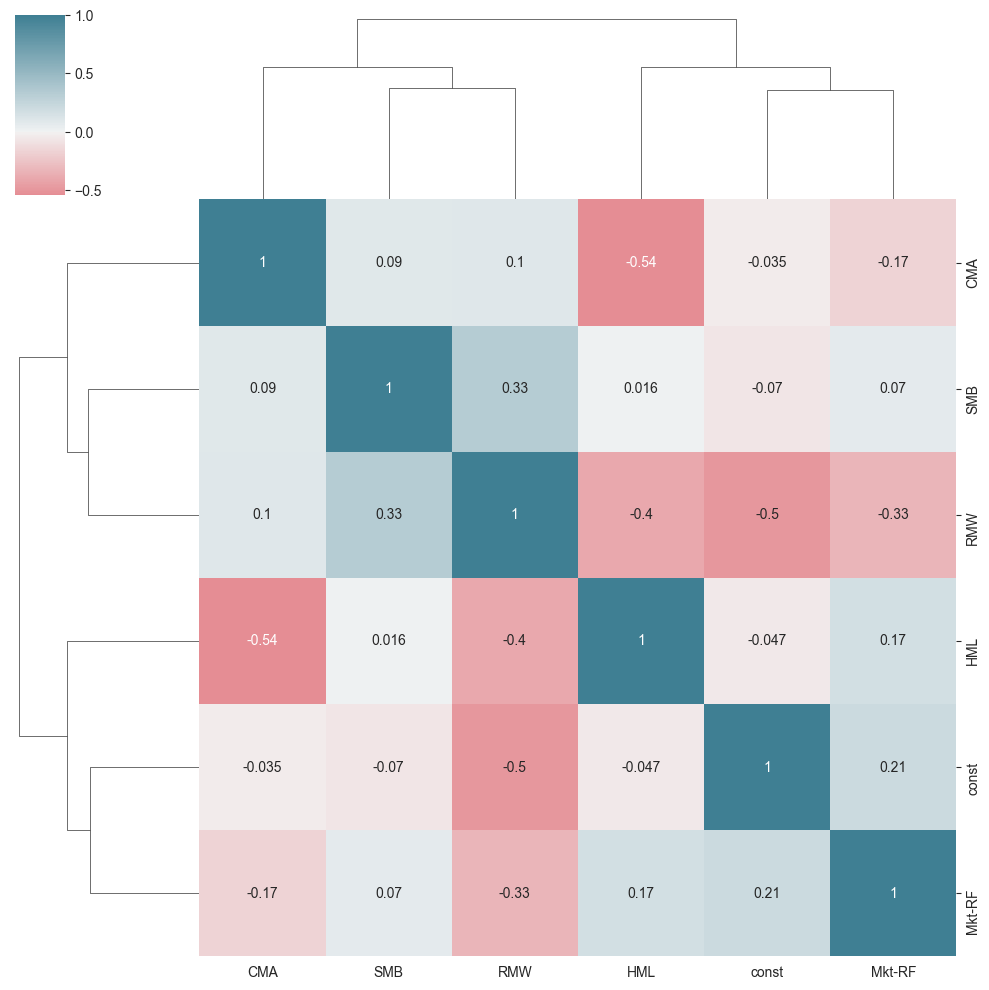

In [89]:
cmap = sns.diverging_palette(10, 220, as_cmap=True)
sns.clustermap(betas.corr(), annot=True, cmap=cmap, center=0);

In [90]:
data = (data
        .join(betas
              .groupby(level='Ticker')
              .shift()))
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11833 entries, (Timestamp('2021-01-31 00:00:00'), 'A') to (Timestamp('2022-12-31 00:00:00'), 'ZTS')
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   return_1m   11833 non-null  float64
 1   return_2m   11833 non-null  float64
 2   return_3m   11833 non-null  float64
 3   return_6m   11833 non-null  float64
 4   return_9m   11833 non-null  float64
 5   return_12m  11833 non-null  float64
 6   const       495 non-null    float64
 7   Mkt-RF      495 non-null    float64
 8   SMB         495 non-null    float64
 9   HML         495 non-null    float64
 10  RMW         495 non-null    float64
 11  CMA         495 non-null    float64
dtypes: float64(12)
memory usage: 1.4+ MB


### Impute mean for missing factor betas

In [91]:
data.loc[:, factors] = (
    data.groupby('Ticker')[factors]
        .transform(lambda x: x.fillna(x.mean()))
)


## Momentum factors

We can use these results to compute momentum factors based on the difference between returns over longer periods and the most recent monthly return, as well as for the difference between 3 and 12 month returns as follows:

In [92]:
for lag in [2,3,6,9,12]:
    data[f'momentum_{lag}'] = data[f'return_{lag}m'].sub(data.return_1m)
data[f'momentum_3_12'] = data[f'return_12m'].sub(data.return_3m)

## Date Indicators

In [93]:
dates = data.index.get_level_values('Date')
data['year'] = dates.year
data['month'] = dates.month

## Lagged returns

To use lagged values as input variables or features associated with the current observations, we use the .shift() method to move historical returns up to the current period:

In [94]:
for t in range(1, 7):
    data[f'return_1m_t-{t}'] = data.groupby(level='Ticker').return_1m.shift(t)
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11833 entries, (Timestamp('2021-01-31 00:00:00'), 'A') to (Timestamp('2022-12-31 00:00:00'), 'ZTS')
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   return_1m      11833 non-null  float64
 1   return_2m      11833 non-null  float64
 2   return_3m      11833 non-null  float64
 3   return_6m      11833 non-null  float64
 4   return_9m      11833 non-null  float64
 5   return_12m     11833 non-null  float64
 6   const          495 non-null    float64
 7   Mkt-RF         11833 non-null  float64
 8   SMB            11833 non-null  float64
 9   HML            11833 non-null  float64
 10  RMW            11833 non-null  float64
 11  CMA            11833 non-null  float64
 12  momentum_2     11833 non-null  float64
 13  momentum_3     11833 non-null  float64
 14  momentum_6     11833 non-null  float64
 15  momentum_9     11833 non-null  float64
 16  momentum_12    11833

## Target: Holding Period Returns

Similarly, to compute returns for various holding periods, we use the normalized period returns computed previously and shift them back to align them with the current financial features

In [95]:
for t in [1,2,3,6,12]:
    data[f'target_{t}m'] = data.groupby(level='Ticker')[f'return_{t}m'].shift(-t)

In [96]:
cols = ['target_1m',
        'target_2m',
        'target_3m', 
        'return_1m',
        'return_2m',
        'return_3m',
        'return_1m_t-1',
        'return_1m_t-2',
        'return_1m_t-3']

data[cols].dropna().sort_index().head(10)

target_1m  target_2m  target_3m  return_1m  return_2m  \
Date       Ticker                                                          
2021-04-30 A        0.033598   0.051680   0.047111   0.052724   0.047114   
           AAPL    -0.050497   0.021571   0.035841   0.076218   0.041209   
           ABBV     0.015247   0.005099   0.017903   0.042836   0.023466   
           ABT     -0.028564  -0.017432   0.003763   0.005682   0.003088   
           ACGL     0.004533  -0.009743  -0.005996   0.034923   0.052900   
           ACN     -0.026934   0.008277   0.031859   0.052913   0.076706   
           ADBE    -0.007397   0.073342   0.069365   0.069357   0.051608   
           ADI      0.079237   0.062453   0.031569  -0.012381  -0.008572   
           ADM      0.059653  -0.017552  -0.016543   0.107544   0.056298   
           ADP      0.048291   0.033056   0.040461  -0.007853   0.039254   

                   return_3m  return_1m_t-1  return_1m_t-2  return_1m_t-3  
Date       Ticker                                                          
2021-04-30 A        0.036574       0.041534       0.015811       0.015841  
           AAPL    -0.000767       0.007340      -0.079712      -0.005501  
           ABBV     0.032670       0.004455       0.051327      -0.032397  
           ABT     -0.008347       0.000501      -0.030828       0.133326  
           ACGL     0.081294       0.071189       0.140401      -0.129193  
           ACN      0.063346       0.101036       0.037120      -0.070684  
           ADBE     0.034792       0.034155       0.001962      -0.082680  
           ADI      0.014465      -0.004749       0.062157      -0.002708  
           ADM      0.083265       0.007423       0.139283      -0.007935  
           ADP      0.044113       0.088597       0.053900      -0.062883

In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11833 entries, (Timestamp('2021-01-31 00:00:00'), 'A') to (Timestamp('2022-12-31 00:00:00'), 'ZTS')
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   return_1m      11833 non-null  float64
 1   return_2m      11833 non-null  float64
 2   return_3m      11833 non-null  float64
 3   return_6m      11833 non-null  float64
 4   return_9m      11833 non-null  float64
 5   return_12m     11833 non-null  float64
 6   const          495 non-null    float64
 7   Mkt-RF         11833 non-null  float64
 8   SMB            11833 non-null  float64
 9   HML            11833 non-null  float64
 10  RMW            11833 non-null  float64
 11  CMA            11833 non-null  float64
 12  momentum_2     11833 non-null  float64
 13  momentum_3     11833 non-null  float64
 14  momentum_6     11833 non-null  float64
 15  momentum_9     11833 non-null  float64
 16  momentum_12    11833

## Create age proxy

We use quintiles of IPO year as a proxy for company age.

In [98]:
# Filter out missing IPO years
valid_ipos = stocks['ipoyear'].dropna()

print(stocks['ipoyear'])

# Only proceed if there are enough unique values
if valid_ipos.nunique() >= 5:
    ipo_quintiles = pd.qcut(valid_ipos, q=5, labels=range(1, 6), duplicates='drop')
    age = ipo_quintiles.astype(int).to_frame('age')
    data = data.join(age, on='Ticker')
    data['age'] = data['age'].fillna(-1)
else:
    print("Not enough unique IPO years to create quintiles.")


ticker
MSFT     1986.0
AAPL     1980.0
NVDA     1999.0
AMZN     1997.0
GOOGL    2004.0
          ...  
IVZ      1995.0
MHK      1992.0
ENPH     2012.0
APA      1979.0
CZR      2014.0
Name: ipoyear, Length: 502, dtype: float64


## Create dynamic size proxy

We use the marketcap information from the NASDAQ ticker info to create a size proxy.

In [99]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 502 entries, MSFT to CZR
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   marketcap  502 non-null    int64  
 1   ipoyear    501 non-null    float64
 2   sector     502 non-null    object 
dtypes: float64(1), int64(1), object(1)
memory usage: 31.9+ KB


Market cap information is tied to currrent prices. We create an adjustment factor to have the values reflect lower historical prices for each individual stock:

In [100]:
size_factor = (monthly_prices
               .loc[data.index.get_level_values('Date').unique(),
                    data.index.get_level_values('Ticker').unique()]
               .sort_index(ascending=False)
               .pct_change()
               .fillna(0)
               .add(1)
               .cumprod())
size_factor.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2022-12-31 to 2021-01-31
Columns: 495 entries, A to EXE
dtypes: float64(495)
memory usage: 93.0 KB


In [101]:
msize = (size_factor
         .mul(stocks
              .loc[size_factor.columns, 'marketcap'])).dropna(axis=1, how='all')

### Create Size indicator as deciles per period

Compute size deciles per month:

In [102]:
data['msize'] = (msize
                 .apply(lambda x: pd.qcut(x, q=10, labels=list(range(1, 11)))
                        .astype(int), axis=1)
                 .stack()
                 .swaplevel())
data.msize = data.msize.fillna(-1)

## Combine data

In [103]:
# Join on the Ticker level of the MultiIndex
data = data.join(stocks[['sector']], on='Ticker')
data['sector'] = data['sector'].fillna('Unknown')

In [104]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 11833 entries, (Timestamp('2021-01-31 00:00:00'), 'A') to (Timestamp('2022-12-31 00:00:00'), 'ZTS')
Data columns (total 34 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   return_1m      11833 non-null  float64
 1   return_2m      11833 non-null  float64
 2   return_3m      11833 non-null  float64
 3   return_6m      11833 non-null  float64
 4   return_9m      11833 non-null  float64
 5   return_12m     11833 non-null  float64
 6   const          495 non-null    float64
 7   Mkt-RF         11833 non-null  float64
 8   SMB            11833 non-null  float64
 9   HML            11833 non-null  float64
 10  RMW            11833 non-null  float64
 11  CMA            11833 non-null  float64
 12  momentum_2     11833 non-null  float64
 13  momentum_3     11833 non-null  float64
 14  momentum_6     11833 non-null  float64
 15  momentum_9     11833 non-null  float64
 16  momentum_12    11833

## Store data

We will use the data again in several later chapters, starting in [Chapter 7 on Linear Models](../../07_linear_models/README.md).

In [105]:
import pandas as pd
from datetime import datetime

# Load the sample data
data = pd.read_csv('sample_data.csv')

# Convert the 'Date' column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Set a MultiIndex with ['Date', 'Ticker']
data.set_index(['Date', 'Ticker'], inplace=True)

# Filter rows where Date <= March 1, 2018 using a boolean mask
filtered_data = data[data.index.get_level_values('Date') <= datetime(2018, 3, 1)]

# Save the filtered result to HDF5
DATA_STORE = 'data_store.h5'
with pd.HDFStore(DATA_STORE) as store:
    store.put('engineered_features', filtered_data.sort_index())
    print(store.info())


<class 'pandas.io.pytables.HDFStore'>
File path: data_store.h5
/engineered_features            frame        (shape->[1,34])    
/prices                         frame        (shape->[373423,6])
/stocks                         frame        (shape->[502,3])   


## Create Dummy variables

For most models, we need to encode categorical variables as 'dummies' (one-hot encoding):

In [106]:
dummy_data = pd.get_dummies(data,
                            columns=['year','month', 'msize', 'age',  'sector'],
                            prefix=['year','month', 'msize', 'age', ''],
                            prefix_sep=['_', '_', '_', '_', ''])
dummy_data = dummy_data.rename(columns={c:c.replace('.0', '') for c in dummy_data.columns})
dummy_data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 100 entries, (Timestamp('2022-09-30 00:00:00'), 'AES') to (Timestamp('2021-06-30 00:00:00'), 'AVGO')
Data columns (total 60 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   return_1m               100 non-null    float64
 1   return_2m               100 non-null    float64
 2   return_3m               100 non-null    float64
 3   return_6m               100 non-null    float64
 4   return_9m               100 non-null    float64
 5   return_12m              100 non-null    float64
 6   const                   1 non-null      float64
 7   Mkt-RF                  100 non-null    float64
 8   SMB                     100 non-null    float64
 9   HML                     100 non-null    float64
 10  RMW                     100 non-null    float64
 11  CMA                     100 non-null    float64
 12  momentum_2              100 non-null    float64
 13  momentum_3      